# Data Challenge 9 — Feature Engineering & Feature Selection

**Format:** Instructor Guidance → You Do (Students) → We Share (Reflection)

**Goal:** Engineer better predictors (one-hot/dummies, interactions, polynomials), avoid unnecessary complexity, and compare a **Base** vs **Engineered** model on the **same train–test split** using **MAE/RMSE**. Interpret coefficients in units and explain business value.



> Dataset: **NYC Yellow Taxi — Dec 2023** (CSV). Keep code *simple*: light numeric coercion only for your chosen columns.

## Instructor Guidance

**Hint: Use the Lecture Deck, Canvas Reading, and Docs to help you with the code**

**Docs (quick links):**
- One-hot encoding (pandas): https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html  
- OneHotEncoder (sklearn): https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html  
- Train/Test Split: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- MAE / MSE / RMSE: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html  
- OLS (statsmodels): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html  
- OLS Results (coef/p/CIs/resid): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html

### Pseudocode Plan (Feature Engineering + Selection)
1) **Load CSV** → preview columns/shape.  
2) **Pick Y and initial Xs (2–3 numeric)** → keep it simple and decision-time-available.  
3) **Engineer features:**
   - **One-hot** a categorical with a dropped baseline (e.g., `payment_type` or `weekday/weekend`).  
   - **Interaction**: choose a hypothesis-driven pair (e.g., `trip_distance × is_weekend`).  
   - **Polynomial**: add one squared term for a plausible curve (e.g., `trip_distance²`).  
4) **Build Base vs Engineered design matrices** (add intercept).  
5) **Single train–test split** (80/20, fixed `random_state`) shared by both models.  
6) **Fit on TRAIN**, **predict on TEST** for both models; compute **MAE/RMSE** (units of Y).  
7) **Interpretation**: write unit-based coefficient sentences; note baseline category for dummies.  
8) **Light selection**: if Engineered model doesn’t beat Base on TEST (or adds complexity w/o value), prefer Base.  
9) **Diagnostics (quick)**: residuals vs fitted (train); note any cones (heteroskedasticity).  
10) **Stakeholder one-liner**: which model, why (TEST metrics in units), and what the added features *mean*.
markdown


## You Do — Student Section
Work in pairs. Comment your choices briefly. Keep code simple—only coerce the columns you use.

### Step 0 — Setup & Imports

In [1]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Step 1 — Load CSV & Preview
- Point to your **Dec 2023** taxi CSV.
- Print **shape** and **columns**.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [8]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/2023_Yellow_Taxi_Trip_Data_20251015.csv', low_memory=False)
# converting to numeric
num_cols = ['fare_amount', 'tip_amount', 'trip_distance','total_amount','RatecodeID']
for c in num_cols:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
    )
df = df[(df['fare_amount'] > 0) & (df['tip_amount'] >= 0) & (df['trip_distance'] > 0)]
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=num_cols)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.1)
    Q3 = df[column].quantile(0.90)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = remove_outliers_iqr(df, 'fare_amount')
df = remove_outliers_iqr(df, 'trip_distance')
y = df['fare_amount']
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,12/01/2023 04:11:39 PM,12/01/2023 04:19:13 PM,2.0000,0.6900,1.0000,N,141,140,1,7.9000,2.5000,0.5000,3.0000,0.0000,1.0000,17.4000,2.5000,0.0000
1,1,12/01/2023 04:11:39 PM,12/01/2023 04:20:41 PM,3.0000,1.1000,1.0000,N,236,263,2,10.0000,5.0000,0.5000,0.0000,0.0000,1.0000,16.5000,2.5000,0.0000
3,2,12/01/2023 04:11:39 PM,12/01/2023 04:20:38 PM,1.0000,1.5700,1.0000,N,48,239,4,10.7000,2.5000,0.5000,0.0000,0.0000,1.0000,17.2000,2.5000,0.0000
4,1,12/01/2023 04:11:39 PM,12/01/2023 04:34:39 PM,2.0000,3.0000,1.0000,N,164,211,1,21.9000,5.0000,0.5000,3.0000,0.0000,1.0000,31.4000,2.5000,0.0000
6,2,12/01/2023 04:11:40 PM,12/01/2023 04:23:51 PM,1.0000,1.2400,1.0000,N,142,162,4,11.4000,2.5000,0.5000,0.0000,0.0000,1.0000,17.9000,2.5000,0.0000


In [9]:
# Mapping RatecodeID to descriptive labels
df['RatecodeID'] = df['RatecodeID'].astype('int')
rate_code_mapping = {
    1: 'Standard rate',
    2: 'JFK',
    3: 'Newark',
    4: 'Nassau or Westchester',
    5: 'Negotiated fare',
    6: 'Group ride',
    99: 'Null/unknown'
}

df['RatecodeID'] = df['RatecodeID'].map(rate_code_mapping).astype('category')
df['RatecodeID'] = pd.Categorical(df['RatecodeID'], categories=['Standard rate', 'JFK', 'Newark','Nassau or Westchester','Negotiated fare','Group ride','Null/unknown'], ordered=True)
df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
3310900,2,12/31/2023 11:59:59 PM,01/01/2024 12:27:43 AM,2.0000,1.4600,Standard rate,N,186,164,2,22.6000,1.0000,0.5000,0.0000,0.0000,1.0000,27.6000,2.5000,0.0000
3310901,2,01/01/2024 12:01:34 AM,01/01/2024 12:05:41 AM,1.0000,0.7100,Standard rate,N,234,68,2,6.5000,1.0000,0.5000,0.0000,0.0000,1.0000,11.5000,2.5000,0.0000
3310902,2,01/01/2024 12:01:58 AM,01/01/2024 12:10:04 AM,3.0000,1.7000,Standard rate,N,234,144,1,10.7000,1.0000,0.5000,2.3600,0.0000,1.0000,18.0600,2.5000,0.0000
3310905,2,01/03/2024 06:43:26 PM,01/03/2024 06:43:29 PM,2.0000,0.0100,Negotiated fare,N,95,95,1,86.6900,0.0000,0.0000,17.5400,0.0000,1.0000,105.2300,0.0000,0.0000
3310906,2,01/03/2024 07:42:57 PM,01/03/2024 08:15:55 PM,1.0000,16.6700,Standard rate,N,132,165,1,65.3000,0.0000,0.5000,5.0000,0.0000,1.0000,73.5500,0.0000,1.7500


### Step 2 —  Pick Target **Y** and Predictors **Xs** (choose 2–3 numeric)

- **Avoid** using an X that directly defines Y (e.g., `total_amount` when Y = `fare_amount`).
- Coerce **only these columns** to numeric; drop NA rows.

In [10]:
y = df['fare_amount']
x_base1 = df['RatecodeID']
x_base2 = df['trip_distance']

### Step 3 —  Engineer New Features (One-hot, Interaction, Polynomial)

Pick **one** categorical to one-hot (drop baseline). Options that usually exist:

- `payment_type` (codes): treat as categorical strings for clarity, then one-hot with drop_first=True, or  
- derive **weekday/weekend** from `tpep_pickup_datetime` if present.

Then add **one interaction** and **one squared term** guided by a business hypothesis.

In [11]:
df['RatecodeID_x'] = df['RatecodeID']
# hot coding RateCodeID
df = pd.get_dummies(df, columns=['RatecodeID_x'], prefix='RC', drop_first=True)

# Scaling trip_distance before squaring
scaler = StandardScaler()
df['trip_distance_scaled'] = scaler.fit_transform(df[['trip_distance']])

# Creating a squared term (distance square) 
df['trip_distance_sq'] = df['trip_distance_scaled'] ** 2

df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,congestion_surcharge,airport_fee,RC_JFK,RC_Newark,RC_Nassau or Westchester,RC_Negotiated fare,RC_Group ride,RC_Null/unknown,trip_distance_scaled,trip_distance_sq
0,2,12/01/2023 04:11:39 PM,12/01/2023 04:19:13 PM,2.0000,0.6900,Standard rate,N,141,140,1,...,2.5000,0.0000,0,0,0,0,0,0,-0.6296,0.3964
1,1,12/01/2023 04:11:39 PM,12/01/2023 04:20:41 PM,3.0000,1.1000,Standard rate,N,236,263,2,...,2.5000,0.0000,0,0,0,0,0,0,-0.5234,0.2739
3,2,12/01/2023 04:11:39 PM,12/01/2023 04:20:38 PM,1.0000,1.5700,Standard rate,N,48,239,4,...,2.5000,0.0000,0,0,0,0,0,0,-0.4016,0.1613
4,1,12/01/2023 04:11:39 PM,12/01/2023 04:34:39 PM,2.0000,3.0000,Standard rate,N,164,211,1,...,2.5000,0.0000,0,0,0,0,0,0,-0.0312,0.0010
6,2,12/01/2023 04:11:40 PM,12/01/2023 04:23:51 PM,1.0000,1.2400,Standard rate,N,142,162,4,...,2.5000,0.0000,0,0,0,0,0,0,-0.4871,0.2373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3310900,2,12/31/2023 11:59:59 PM,01/01/2024 12:27:43 AM,2.0000,1.4600,Standard rate,N,186,164,2,...,2.5000,0.0000,0,0,0,0,0,0,-0.4301,0.1850
3310901,2,01/01/2024 12:01:34 AM,01/01/2024 12:05:41 AM,1.0000,0.7100,Standard rate,N,234,68,2,...,2.5000,0.0000,0,0,0,0,0,0,-0.6244,0.3899
3310902,2,01/01/2024 12:01:58 AM,01/01/2024 12:10:04 AM,3.0000,1.7000,Standard rate,N,234,144,1,...,2.5000,0.0000,0,0,0,0,0,0,-0.3680,0.1354
3310905,2,01/03/2024 06:43:26 PM,01/03/2024 06:43:29 PM,2.0000,0.0100,Negotiated fare,N,95,95,1,...,0.0000,0.0000,0,0,0,1,0,0,-0.8057,0.6492


In [12]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'RC_JFK',
       'RC_Newark', 'RC_Nassau or Westchester', 'RC_Negotiated fare',
       'RC_Group ride', 'RC_Null/unknown', 'trip_distance_scaled',
       'trip_distance_sq'],
      dtype='object')

### Step 4 — Build **Base** and **Engineered** Design Matrices

- **Base** = intercept + base predictors (Xs you assigned in Step 2) 
- **Engineered** = intercept + base predictors + engineered columns (dummies + interaction + polynomial)


In [13]:
y = df['fare_amount']

X_all = df[['RC_Nassau or Westchester', 'RC_Negotiated fare','RC_Newark',
       'RC_Null/unknown', 'RC_Group ride','trip_distance_sq','RatecodeID','trip_distance','fare_amount']]

### Step 5 — Single Train–Test Split (Shared by Both Models)

Use one split so Base and Engineered are comparable.

In [14]:
# splitting
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, 
    test_size=0.2,
    random_state= 42,
    shuffle= True       
)
# BASE FEATURES
X_base_train = sm.add_constant(X_train[['RatecodeID','trip_distance']])
X_base_test = sm.add_constant(X_test[['RatecodeID','trip_distance']])

# ENGINEERED FEATURES
X_engineered_train = sm.add_constant(X_train[['RC_Nassau or Westchester', 'RC_Negotiated fare','RC_Newark',
       'RC_Null/unknown', 'RC_Group ride','trip_distance_sq']])
X_engineered_test = sm.add_constant(X_test[['RC_Nassau or Westchester', 'RC_Negotiated fare','RC_Newark',
       'RC_Null/unknown', 'RC_Group ride','trip_distance_sq']])




### Step 6 — Fit on TRAIN, Predict on TEST, Compute **MAE/RMSE** (units of Y)

In [20]:
# Fit models
#model_base = sm.OLS(y_train, X_base_train).fit()  # can fit model with string categorical variable
model_engineered = sm.OLS(y_train, X_engineered_train).fit()

#  Evaluate on test set
#pred_base = model_base.predict(X_base_test)
pred_engineered = model_engineered.predict(X_engineered_test)

model_engineered.summary()

# Calculate MAE and RMSE

test_mae = mean_absolute_error(y_test, pred_engineered)
test_rmse = np.sqrt(mean_squared_error(y_test, pred_engineered))

print(f"MAE: ${test_mae:.2f}")
print(f"RMSE: ${test_rmse:.2f}")

MAE: $7.21
RMSE: $9.18


### Step 7 — Interpret Key Coefficients (Plain Language)

Write **unit-based** interpretations for 2–3 impactful coefficients **in the Engineered model**, noting:
- The **baseline** category for dummies (the dropped category).
- **ANSWER:** the dropped category is the standard rate, which is the most common, this is absorbed in the intercept and make it the baseline. the baseline fare amount considering that the ratecode is standard is 14$.
-the negotiated fare has the highest slope 36$. This suggest that the fare amount increases significantly when the the Ratecode is Negociated_fare. Holding all other predictors constant, trips with negociated fares cost 36$ more than those with standard rate.
- **Interaction** meaning (change in slope under the condition).
- **Polynomial** meaning (curve: does effect rise then taper?).
- **Answer** The trip_distance squared have a slope of $4.11, meaning for any additional distance unit "mile", the fare amount increases by $4.11. 


*(Use this template; edit to your variables/units):*

- **Dummy (pay_…):** Compared to baseline **[dropped category]**, the expected **Y** is **β** higher/lower, holding other features constant.  
- **Interaction (dist×weekend):** On weekends, each additional **mile** changes **Y** by **β_interaction** *more/less* than on weekdays, holding other features constant.  
- **Polynomial (distance²):** The marginal effect of distance changes with distance; the negative/positive β on distance² indicates **diminishing/increasing** returns.

### Step 8 —  Quick Diagnostics (Train Residuals) — Engineered Model
- **Residuals vs Fitted:** random cloud ≈ good; cone/funnel suggests non-constant variance.  
- **Q–Q plot:** points roughly along diagonal (normality for inference).  
- **Durbin–Watson:** printed in `eng_model.summary()` (~2 suggests independence).

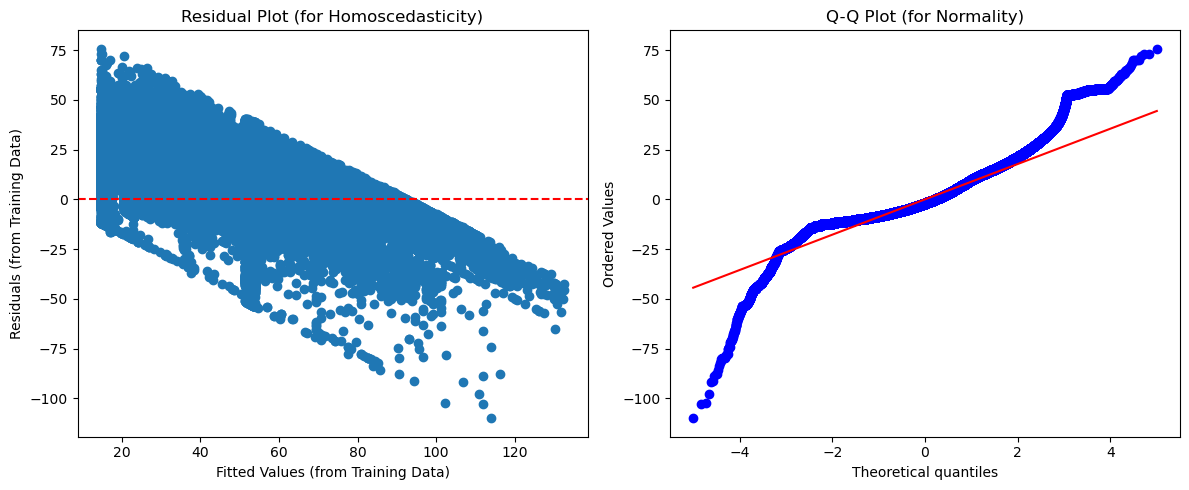

In [21]:
residuals = model_engineered.resid
fitted = model_engineered.fittedvalues
# 1. Plot for Homoscedasticity
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot (for Homoscedasticity)')
plt.xlabel('Fitted Values (from Training Data)')
plt.ylabel('Residuals (from Training Data)')

# 2. Q-Q Plot for Normality
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot (for Normality)')

plt.tight_layout()
plt.show()

## We Share — Reflection & Wrap‑Up

**Notes on Feature Selection**
- If **Engineered** doesn’t beat **Base** on TEST (or gains are tiny), prefer **Base** for simplicity.  
- If two engineered features are redundant (e.g., highly correlated dummies), consider dropping one.  
- Keep features that improve TEST error **and** you can explain to a stakeholder.


Write **2 short paragraphs** and be specific:


1) **Which model would you deploy today—Base or Engineered—and why?**  
Use **TEST MAE/RMSE in units**, your coefficient interpretations (baseline/interaction/polynomial), and any residual observations.
- I would deploy the engineered model because I cannot run the model with a categorical variable without transforming it, since I need to "one-hot encode" it before applying the model, using the engineered model is more practical.
2) **What engineered feature was most useful (or not)?**  
Explain the **business logic** behind it and whether it earned its place on the TEST set. If not, what would you try next (different interaction, different categorical, or simplifying features)?
- The encoded RatecodeID was very useful for this model because the fare amount depends heavily on this field. Since it was a categorical variable, it was important to transoform it in order to make it fit in the model. As the fare amount vary based on the type of ride JFK, Nassau, standard etc, this is a useful feature to captures that relationship and make a more reliable prediction. 
